# Notebook Kiểm Chứng Nhanh - DS317
Phục vụ điền số liệu cho Bản Đề Xuất Đề Tài Datathon 2026.

In [ ]:
import os
# Tải file từ Google Drive bằng gdown
!gdown --id 19YBZRmrlM-vI-FTyP8iF4Cv8hzlfS1kh -O datathon_dataset.zip

# Giải nén
if os.path.exists('datathon_dataset.zip'):
    !unzip -o datathon_dataset.zip
    print("Giải nén dữ liệu thành công!")
else:
    print("Tải file không thành công, vui lòng kiểm tra lại quyền chia sẻ link Drive.")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19YBZRmrlM-vI-FTyP8iF4Cv8hzlfS1kh
From (redirected): https://drive.google.com/uc?id=19YBZRmrlM-vI-FTyP8iF4Cv8hzlfS1kh&confirm=t&uuid=2bbd2ae8-9d72-40d9-8262-8933c709368c
To: /content/datathon_dataset.zip
100% 29.1M/29.1M [00:00<00:00, 37.3MB/s]
Archive:  datathon_dataset.zip
  inflating: baseline.ipynb          
  inflating: customers.csv           
  inflating: geography.csv           
  inflating: inventory.csv           
  inflating: order_items.csv         
  inflating: orders.csv              
  inflating: payments.csv            
  inflating: products.csv            
  inflating: promotions.csv          
  inflating: returns.csv             
  inflating: reviews.csv             
  inflating: sales.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (14, 6)

dir_path = 'datathon-2026-round-1'

## 1. Kiểm tra Nhãn: Độ lệch `sales` và `order_items` với Chiết khấu (Discounts)

In [ ]:
order_items = pd.read_csv(f"order_items.csv", low_memory=False)
orders = pd.read_csv(f"orders.csv")
sales = pd.read_csv(f"sales.csv")

# Gộp order_items và orders để lấy ngày
merged = pd.merge(order_items, orders[['order_id', 'order_date']], on='order_id')
merged['gross_revenue'] = merged['quantity'] * merged['unit_price']
merged['net_revenue'] = merged['gross_revenue'] - merged['discount_amount'].fillna(0)

# Tổng hợp theo ngày
daily_orders = merged.groupby('order_date').agg(
    gross_revenue=('gross_revenue', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    discount=('discount_amount', 'sum')
).reset_index()

daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])
sales['Date'] = pd.to_datetime(sales['Date'])
merged_sales = pd.merge(sales, daily_orders, left_on='Date', right_on='order_date', how='inner')

# So sánh
print("Does sales.Revenue == order_items.gross_revenue?", np.allclose(merged_sales['Revenue'], merged_sales['gross_revenue']))

discount_pct_gross = merged_sales['discount'] / merged_sales['gross_revenue']
print("\nTrung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross):", round(discount_pct_gross.mean() * 100, 2), "%")
print("Các cụm phần trăm chiết khấu phổ biến:")
print((discount_pct_gross * 100).round(1).value_counts().head(10))

Does sales.Revenue == order_items.gross_revenue? True

Trung bình phần trăm chiết khấu trên doanh thu gộp (discount/gross): 5.17 %
Các cụm phần trăm chiết khấu phổ biến:
0.0     2127
20.0     384
10.0     264
12.0     231
18.0     220
0.9       56
0.8       49
1.0       33
0.7       16
2.0       12
Name: count, dtype: int64


## 2. Tính Chi phí làm sai (Phần 2.1)
- Tính lại % nhu cầu bị mất và số tiền tương ứng
- So sánh lãi gộp mất do hết hàng vs lãi gộp âm do xả hàng

In [ ]:
inventory = pd.read_csv("inventory.csv")

# Tính nhu cầu
inventory['total_demand'] = inventory['units_sold'] / inventory['fill_rate']
inventory['lost_demand'] = inventory['total_demand'] - inventory['units_sold']

total_units_sold = inventory['units_sold'].sum()
total_lost_demand = inventory['lost_demand'].sum()
total_demand = inventory['total_demand'].sum()

lost_demand_pct = (total_lost_demand / total_demand) * 100
print(f"1. Tỉ lệ nhu cầu bị mất: {lost_demand_pct:.2f}%")

# Tính doanh thu bị mất
product_prices = order_items.groupby('product_id')['unit_price'].mean().reset_index()
inventory_with_price = pd.merge(inventory, product_prices, on='product_id', how='left')
inventory_with_price['lost_revenue'] = inventory_with_price['lost_demand'] * inventory_with_price['unit_price']

total_lost_revenue = inventory_with_price['lost_revenue'].sum()
print(f"2. Tổng doanh thu bị mất do hết hàng (Triệu VNĐ): {total_lost_revenue / 1e6:.2f}")

# Lãi gộp mất đi do hết hàng (ước tính biên lãi gộp = 12.5%)
gross_profit_lost = total_lost_revenue * 0.125
print(f"3. Lãi gộp mất đi do hết hàng (Triệu VNĐ): {gross_profit_lost / 1e6:.2f}")

# Tổng lãi gộp âm của những ngày lỗ
sales['gross_profit'] = sales['Revenue'] - sales['COGS']
loss_days = sales[sales['gross_profit'] < 0]
total_negative_gp = loss_days['gross_profit'].sum()
print(f"4. Tổng lãi gộp âm trong {len(loss_days)} ngày xả hàng (Triệu VNĐ): {total_negative_gp / 1e6:.2f}")

print("\n=> KẾT LUẬN: Dự báo cao tốn kém hơn vì làm âm", abs(total_negative_gp)/1e6, "triệu, lớn hơn lãi gộp đánh mất là", gross_profit_lost/1e6, "triệu.")

1. Tỉ lệ nhu cầu bị mất: 8.77%
2. Tổng doanh thu bị mất do hết hàng (Triệu VNĐ): 428.54
3. Lãi gộp mất đi do hết hàng (Triệu VNĐ): 53.57
4. Tổng lãi gộp âm trong 382 ngày xả hàng (Triệu VNĐ): -192.22

=> KẾT LUẬN: Dự báo cao tốn kém hơn vì làm âm 192.21936674 triệu, lớn hơn lãi gộp đánh mất là 53.56778773417992 triệu.


## 3. Vẽ biểu đồ EDA
Yêu cầu: Nhãn biểu đồ dùng 'Triệu' thay vì 'Tỷ VNĐ'.

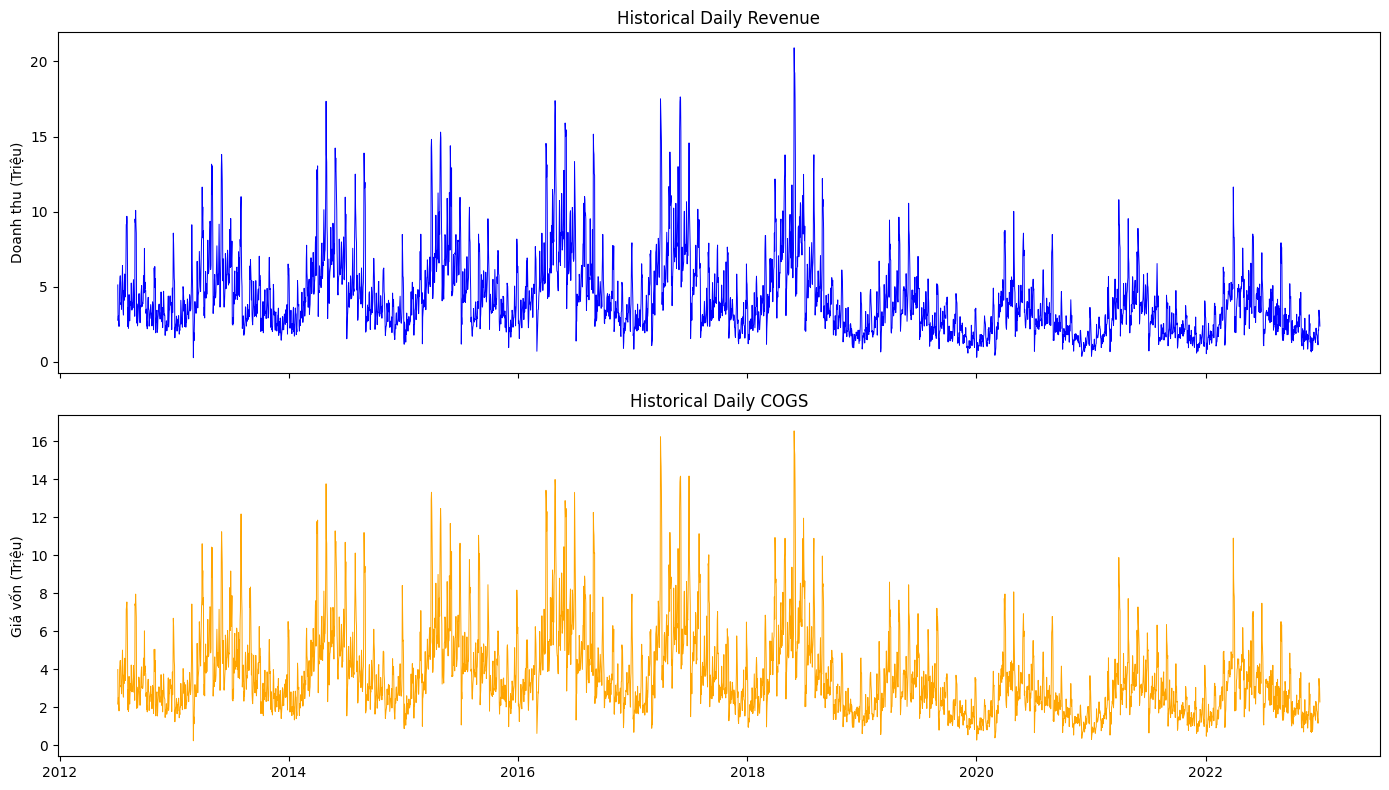

In [ ]:
# Biểu đồ Doanh thu (quy ra Triệu VNĐ)
sales['Revenue_Million'] = sales['Revenue'] / 1e6
sales['COGS_Million'] = sales['COGS'] / 1e6

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(sales['Date'], sales['Revenue_Million'], lw=0.7, color='blue')
axes[0].set_title('Historical Daily Revenue')
axes[0].set_ylabel('Doanh thu (Triệu)')

axes[1].plot(sales['Date'], sales['COGS_Million'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS')
axes[1].set_ylabel('Giá vốn (Triệu)')

plt.tight_layout()
plt.show()

## 4. Kiểm chứng nhanh PA3 (Bảng 4.1)
Baseline seasonal-naive và SARIMA trên chuỗi ngày.

In [ ]:
sales_ts = sales[['Date', 'Revenue']].copy()
sales_ts = sales_ts.sort_values('Date').set_index('Date')

train = sales_ts.loc[:'2020-12-31']
val = sales_ts.loc['2021-01-01':'2021-12-31']

def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

y_combined = pd.concat([train['Revenue'], val['Revenue']])

print("ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION 2021\n")

# Seasonal Naive (s=364 ngày)
t0 = time.time()
pred_snaive_364 = y_combined.shift(364).loc['2021-01-01':'2021-12-31']
time_snaive = time.time() - t0
print(f"[Seasonal Naive (s=364)]")
print(f"WMAPE: {wmape(val['Revenue'], pred_snaive_364)*100:.2f}%")
print(f"MAE: {mae(val['Revenue'], pred_snaive_364)/1e6:.2f} Triệu")
print(f"Thời gian chạy: {time_snaive:.2f}s\n")

# SARIMA
t0 = time.time()
# Để demo nhanh, dùng bộ tham số cơ bản SARIMA(1,1,1)(0,1,1,7)
model = SARIMAX(train['Revenue'], order=(1,1,1), seasonal_order=(0,1,1,7))
res = model.fit(disp=False)
pred_sarima = res.predict(start='2021-01-01', end='2021-12-31')
time_sarima = time.time() - t0

print(f"[SARIMA (1,1,1)(0,1,1,7)]")
print(f"WMAPE: {wmape(val['Revenue'], pred_sarima)*100:.2f}%")
print(f"MAE: {mae(val['Revenue'], pred_sarima)/1e6:.2f} Triệu")
print(f"Thời gian chạy: {time_sarima:.2f}s")

ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP VALIDATION 2021

[Seasonal Naive (s=364)]
WMAPE: 27.16%
MAE: 0.78 Triệu
Thời gian chạy: 0.00s

[SARIMA (1,1,1)(0,1,1,7)]
WMAPE: 105.19%
MAE: 3.01 Triệu
Thời gian chạy: 8.53s




### Việc 1: Tính lại chi phí làm sai

**Giả định:** Coi toàn bộ lỗ của các ngày có lãi gộp âm là do nhập thừa hàng và phải xả lỗ.
Doanh thu mất được ước theo từng SKU × tháng: doanh thu thực tế × (1/fill_rate − 1).

In [ ]:
import numpy as np
import pandas as pd

DATA = ''  # cùng thư mục với cell 4
order_items = pd.read_csv(f"{DATA}order_items.csv", low_memory=False)
orders = pd.read_csv(f"{DATA}orders.csv", parse_dates=["order_date"])
sales = pd.read_csv(f"{DATA}sales.csv", parse_dates=["Date"])
inventory = pd.read_csv(f"{DATA}inventory.csv", parse_dates=["snapshot_date"])

print("Các trạng thái đơn:", orders["order_status"].unique())
orders_ok = orders[orders["order_status"].str.lower() != "cancelled"]

# Doanh thu ròng từng dòng hàng, bỏ đơn hủy (dùng lại ở cell 15)
items = order_items.merge(orders_ok[["order_id", "order_date"]], on="order_id")
items["net_revenue"] = items["quantity"] * items["unit_price"] - items["discount_amount"].fillna(0)
items["month"] = items["order_date"].dt.to_period("M")

# (1) Doanh thu mất: ghép theo SKU × tháng
rev_pm = items.groupby(["product_id", "month"])[["net_revenue"]].sum().reset_index()
inv = inventory[["product_id", "snapshot_date", "fill_rate"]].copy()
if inv["fill_rate"].max() > 1:          # phòng trường hợp lưu theo %
    inv["fill_rate" ] = inv["fill_rate"] / 100
inv["month"] = inv["snapshot_date"].dt.to_period("M")
inv = inv.merge(rev_pm, on=["product_id", "month"], how="inner")
inv = inv[inv["fill_rate"] > 0]
inv["lost_revenue"] = inv["net_revenue"] * (1 / inv["fill_rate"] - 1)
lost_revenue = inv["lost_revenue"].sum()

# (2) Biên lãi gộp ngày bình thường (bỏ các ngày lỗ)
s = sales.copy()
s["gp"] = s["Revenue"] - s["COGS"]
s["gp_pct"] = s["gp"] / s["Revenue"]
normal_margin = s.loc[s["gp"] >= 0, "gp_pct"].median()

# (3) Lãi mất do hết hàng, (4) lỗ xả hàng
profit_lost = lost_revenue * normal_margin
loss_days = s[s["gp"] < 0]
clearance_loss = -loss_days["gp"].sum()

print("=== CHI PHÍ CỦA VIỆC LÀM SAI ===")
print(f"Số snapshot ghép được doanh thu: {len(inv):,}")
print(f"1. Doanh thu mất do hết hàng:      {lost_revenue/1e6:,.1f} triệu")
print(f"2. Biên lãi gộp ngày bình thường:  {normal_margin*100:.1f}%")
print(f"3. Lãi mất do hết hàng (dự báo thấp): {profit_lost/1e6:,.1f} triệu")
print(f"4. Lỗ xả hàng {len(loss_days)} ngày (dự báo cao): {clearance_loss/1e6:,.1f} triệu")
worse = "Dự báo THẤP (hết hàng)" if profit_lost > clearance_loss else "Dự báo CAO (xả lỗ)"
print(f"\n=> KẾT LUẬN: {worse} tốn kém hơn.")

Các trạng thái đơn: ['delivered' 'returned' 'shipped' 'cancelled' 'paid' 'created']
=== CHI PHÍ CỦA VIỆC LÀM SAI ===
Số snapshot ghép được doanh thu: 55,546
1. Doanh thu mất do hết hàng:      1,255.6 triệu
2. Biên lãi gộp ngày bình thường:  18.5%
3. Lãi mất do hết hàng (dự báo thấp): 232.0 triệu
4. Lỗ xả hàng 382 ngày (dự báo cao): 192.2 triệu

=> KẾT LUẬN: Dự báo THẤP (hết hàng) tốn kém hơn.


### Việc 2: Chạy lại baseline PA3 với Dự báo Cuốn chiếu (Rolling Forecast)

In [ ]:
import time
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Chuỗi doanh thu ngày theo định nghĩa PA1 (bỏ đơn hủy, trừ chiết khấu)
daily = items.groupby("order_date")["net_revenue"].sum().asfreq("D", fill_value=0)
val = daily.loc["2021-01-01":"2021-12-31"]

def wmape(y, p): return np.abs(y - p).sum() / y.sum()
def mae(y, p):   return np.abs(y - p).mean()

# A. Seasonal-naive: lấy cùng thứ, cách 364 ngày
t0 = time.time()
pred_sn = daily.shift(364).loc[val.index]
t_sn = time.time() - t0

# B. SARIMA dự báo từng đợt 28 ngày, train từ 2019 (sau điểm gãy), trên log doanh thu
t0 = time.time()
y_log = np.log1p(daily.loc["2019-01-01":])
preds, cutoff = [], pd.Timestamp("2020-12-31")
while cutoff < val.index[-1]:
    res = SARIMAX(y_log.loc[:cutoff], order=(1, 1, 1),
                  seasonal_order=(0, 1, 1, 7)).fit(disp=False)
    preds.append(np.expm1(res.forecast(steps=28)))
    cutoff += pd.Timedelta(days=28)
pred_sa = pd.concat(preds).reindex(val.index)
t_sa = time.time() - t0

summary = pd.DataFrame({
    "Mô hình": ["Seasonal-naive (364 ngày)", "SARIMA(1,1,1)(0,1,1,7), 28 ngày/lần"],
    "WMAPE (%)": [round(wmape(val, pred_sn) * 100, 2), round(wmape(val, pred_sa) * 100, 2)],
    "MAE (triệu)": [round(mae(val, pred_sn) / 1e6, 3), round(mae(val, pred_sa) / 1e6, 3)],
    "Thời gian (giây)": [round(t_sn, 2), round(t_sa, 2)],
})
display(summary)
beat = wmape(val, pred_sa) < wmape(val, pred_sn)
print("=> KẾT LUẬN: SARIMA", "VƯỢT" if beat else "KHÔNG vượt", "seasonal-naive trên validation 2021.")

,Mô hình,WMAPE (%),MAE (triệu),Thời gian (giây)
0,Seasonal-naive (364 ngày),27.82,0.686,0.00
1,"SARIMA(1,1,1)(0,1,1,7), 28 ngày/lần",34.31,0.846,39.78


=> KẾT LUẬN: SARIMA KHÔNG vượt seasonal-naive trên validation 2021.
